# ICU Stress Early-Warning Modeling — Controlled Experimental Framework

Evaluates early-warning models for ICU stress under strict safeguards: locked threshold, chronological split, no temporal leakage. Two logistic regression models (v1: ICU-only, v2: ICU + respiratory) are compared against a heuristic baseline.

**Differs from `feature_eng_modeling.ipynb`**: that notebook explores signals and iterates models; this one applies controlled evaluation with identical conditions across all methods.

**Constraints**: No threshold recomputation, no time-series shuffling, no tree-based models, forward-looking labels only, all evaluation on unseen test period.

## 1. Data Loading & Regime Definition

Loads the cleaned HHS dataset and restricts to the **post-Omicron regime** (2022-06-01 onward) — the early pandemic period introduced extreme volatility that no longer reflects current ICU dynamics.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)

# Add project root to path
sys.path.insert(0, str(Path.cwd().parent))

# Reproducibility
np.random.seed(42)

In [2]:
# ── Load cleaned dataset ──
data_dir = Path("..") / "data"
data = pd.read_parquet(data_dir / "hhs_cleaned.parquet")

# ── Restrict to post-Omicron regime ──
REGIME_CUTOFF = "2022-06-01"
data = data.loc[REGIME_CUTOFF:]

# ── Ensure datetime index integrity ──
assert isinstance(data.index, pd.DatetimeIndex), "Index must be DatetimeIndex"
data = data.sort_index()

# ── Check for duplicates ──
n_dupes = data.index.duplicated().sum()
print(f"Duplicate index entries: {n_dupes}")
assert n_dupes == 0, "Duplicate dates detected — resolve before proceeding"

# ── Check for missing ICU utilization ──
icu_col = "adult_icu_bed_utilization"
n_missing_icu = data[icu_col].isna().sum()
print(f"Missing ICU utilization values: {n_missing_icu}")
assert n_missing_icu == 0, "Missing ICU utilization — cannot proceed without target signal"

print(f"\nRegime window: {data.index.min().date()} to {data.index.max().date()}")
print(f"Total observations: {len(data)}")
print(f"Columns: {list(data.columns)}")

Duplicate index entries: 0
Missing ICU utilization values: 0

Regime window: 2022-06-01 to 2024-04-27
Total observations: 697
Columns: ['icu_patients_confirmed_influenza', 'adult_icu_bed_utilization', 'inpatient_beds_used_covid', 'total_patients_hospitalized_confirmed_influenza', 'adult_icu_bed_covid_utilization', 'previous_day_admission_influenza_confirmed', 'previous_day_admission_adult_covid_confirmed_and_suspected', 'total_adult_patients_hospitalized_covid']


## 2. Initial Training Window Definition

Defines the initial training window as the **first 365 days** after the regime cutoff. Used to: (1) compute the ICU stress threshold (85th percentile) — locked and never recomputed, and (2) serve as the training block for the logistic regression model. Computing the threshold on training only prevents **distribution leakage**.

In [3]:
# ── Define initial training window: first 365 days ──
TRAIN_DAYS = 365
train_end_date = data.index.min() + pd.Timedelta(days=TRAIN_DAYS - 1)

train_window_raw = data.loc[:train_end_date]

print(f"Training window:  {train_window_raw.index.min().date()} to {train_window_raw.index.max().date()}  ({len(train_window_raw)} days)")
print(f"Test window:      after {train_end_date.date()}")
print(f"\nThis training window will be used to:")
print(f"  1. Compute ICU stress threshold (85th percentile)")
print(f"  2. Serve as the initial training block for the logistic regression model")

Training window:  2022-06-01 to 2023-05-31  (365 days)
Test window:      after 2023-05-31

This training window will be used to:
  1. Compute ICU stress threshold (85th percentile)
  2. Serve as the initial training block for the logistic regression model


## 3. Compute ICU Stress Threshold (Training Window Only)

Computes the **85th percentile** of adult ICU bed utilization from the training window only. This value is stored as a **fixed scalar** and never recomputed. The 85th percentile represents sustained operational strain (not rare catastrophic overload) and produces a balanced-enough positive class for classification.

> **This threshold is LOCKED.** No recomputation during test evaluation.

In [4]:
# ── Compute threshold from training window ONLY ──
ICU_PERCENTILE = 0.85
STRESS_THRESHOLD = train_window_raw[icu_col].quantile(ICU_PERCENTILE)

print(f"ICU Stress Threshold (locked)")
print(f"  Percentile:          {ICU_PERCENTILE:.0%}")
print(f"  Utilization value:   {STRESS_THRESHOLD:.4f}  ({STRESS_THRESHOLD * 100:.2f}%)")
print(f"  Computed from:       {len(train_window_raw)} training-window observations")

# ── Definition ──
print(f"\n  Definition:")
print(f"  ICU stress is defined as adult ICU bed utilization exceeding")
print(f"  {STRESS_THRESHOLD * 100:.1f}% at any point in the next 7 days.")
print(f"  This corresponds to the {ICU_PERCENTILE * 100:.0f}th percentile of utilization")
print(f"  observed during the training period")
print(f"  ({train_window_raw.index.min().date()} to {train_window_raw.index.max().date()}).")
print(f"  The early-warning model is trained to predict this event.")

# ── Training distribution context ──
print(f"\n  Training Distribution Context:")
print(f"    Mean utilization:    {train_window_raw[icu_col].mean() * 100:.1f}%")
print(f"    Median utilization:  {train_window_raw[icu_col].median() * 100:.1f}%")
print(f"    Stress threshold:    {STRESS_THRESHOLD * 100:.1f}%")

# ── Evaluation constraint ──
print(f"\n  Evaluation Constraint:")
print(f"  This threshold is LOCKED and will NOT be recomputed.")
print(f"  All labels and downstream evaluation use this fixed value.")

ICU Stress Threshold (locked)
  Percentile:          85%
  Utilization value:   0.7608  (76.08%)
  Computed from:       365 training-window observations

  Definition:
  ICU stress is defined as adult ICU bed utilization exceeding
  76.1% at any point in the next 7 days.
  This corresponds to the 85th percentile of utilization
  observed during the training period
  (2022-06-01 to 2023-05-31).
  The early-warning model is trained to predict this event.

  Training Distribution Context:
    Mean utilization:    72.8%
    Median utilization:  72.6%
    Stress threshold:    76.1%

  Evaluation Constraint:
  This threshold is LOCKED and will NOT be recomputed.
  All labels and downstream evaluation use this fixed value.


## 4. Create 7-Day Forward Stress Label

Binary target: **will ICU utilization exceed the stress threshold at any point in the next 7 days ($t+1$ to $t+7$)?**

- For each day $t$, compute max ICU utilization across $t+1$ to $t+7$. Label = 1 if max > threshold.
- Features use data $\leq t$ only; labels use data from $t+1$ to $t+7$ — strict temporal separation.
- Last 7 rows dropped (incomplete forward window).

In [5]:
# ── Build the 7-day forward-looking stress label ──
# For each day t, take max of utilization from t+1 to t+7
icu_util = data[icu_col]
future_7d_max = pd.Series(
    np.maximum.reduce([icu_util.shift(-k) for k in range(1, 8)]),
    index=icu_util.index
)

# Label: 1 if future 7-day max exceeds threshold, else 0
# Rows where future window is incomplete get NaN (will be dropped)
data["icu_stress_next_7d"] = np.where(
    future_7d_max.notna(),
    (future_7d_max > STRESS_THRESHOLD).astype(int),
    np.nan
)

n_before = len(data)
data = data.dropna(subset=["icu_stress_next_7d"])
data["icu_stress_next_7d"] = data["icu_stress_next_7d"].astype(int)
n_after = len(data)

print(f"Rows before dropping incomplete forward windows: {n_before}")
print(f"Rows after:                                      {n_after}")
print(f"Rows dropped (no full 7-day forward window):     {n_before - n_after}")
print(f"\nLabel distribution:")
print(data["icu_stress_next_7d"].value_counts())
print(f"\nStress prevalence: {data['icu_stress_next_7d'].mean():.2%}")

Rows before dropping incomplete forward windows: 697
Rows after:                                      690
Rows dropped (no full 7-day forward window):     7

Label distribution:
icu_stress_next_7d
0    538
1    152
Name: count, dtype: int64

Stress prevalence: 22.03%


## 5. Minimal Feature Engineering (Model v1)

Creates **two features** from ICU utilization only:
1. **`util_mean_7`** — 7-day backward-looking rolling mean
2. **`util_diff_mean_7`** — 7-day backward-looking rolling mean of daily diffs (slope/momentum)

All rolling windows use `center=False` and `min_periods=7`. Features computed on the full time-ordered dataset before splitting (preserves rolling-window continuity at the split boundary). First 6 rows dropped (insufficient rolling history).

In [6]:
# ── Compute minimal features on full time-ordered dataset ──
# Feature 1: 7-day backward-looking rolling mean of ICU utilization
data["util_mean_7"] = (
    data[icu_col]
    .rolling(window=7, min_periods=7, center=False)
    .mean()
)

# Feature 2: 7-day backward-looking rolling mean of daily differences (slope)
data["util_diff"] = data[icu_col].diff()
data["util_diff_mean_7"] = (
    data["util_diff"]
    .rolling(window=7, min_periods=7, center=False)
    .mean()
)

# ── Drop rows with insufficient rolling history ──
n_before = len(data)
data = data.dropna(subset=["util_mean_7", "util_diff_mean_7"])
n_after = len(data)

print(f"Rows dropped (insufficient rolling history): {n_before - n_after}")
print(f"Remaining rows: {n_after}")
print(f"\nFeature summary:")
print(data[["util_mean_7", "util_diff_mean_7"]].describe())

Rows dropped (insufficient rolling history): 7
Remaining rows: 683

Feature summary:
       util_mean_7  util_diff_mean_7
count   683.000000        683.000000
mean      0.723576          0.000019
std       0.022744          0.002036
min       0.691022         -0.008975
25%       0.704229         -0.001107
50%       0.717455         -0.000024
75%       0.740823          0.001118
max       0.776657          0.007582


### Feature–Label Correlation Heatmap

Correlation of all available signals vs. the stress label (before train/test split). Flags any feature with |correlation| ≥ 0.95 as potential leakage.

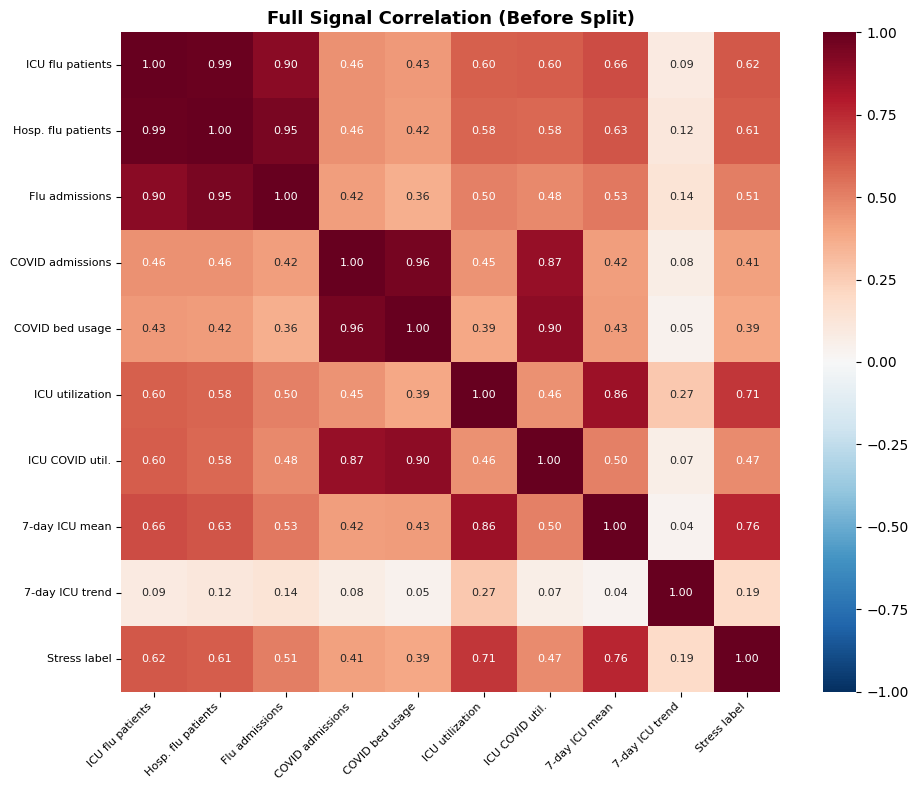

Feature-label correlation (all signals vs stress label):
  ICU flu patients......... +0.6229 ✓
  Hosp. flu patients....... +0.6076 ✓
  Flu admissions........... +0.5080 ✓
  COVID admissions......... +0.4096 ✓
  COVID bed usage.......... +0.3875 ✓
  ICU utilization.......... +0.7149 ✓
  ICU COVID util........... +0.4743 ✓
  7-day ICU mean........... +0.7579 ✓
  7-day ICU trend.......... +0.1883 ✓


In [7]:
# ── Feature–label correlation heatmap (full dataset, before split) ──
# Include all available signals + engineered features vs stress label
FEATURES = ["util_mean_7", "util_diff_mean_7"]
TARGET = "icu_stress_next_7d"

all_signals = [
    "icu_patients_confirmed_influenza",
    "total_patients_hospitalized_confirmed_influenza",
    "previous_day_admission_influenza_confirmed",
    "previous_day_admission_adult_covid_confirmed_and_suspected",
    "inpatient_beds_used_covid",
    "adult_icu_bed_utilization",
    "adult_icu_bed_covid_utilization",
    "util_mean_7",
    "util_diff_mean_7",
]

heatmap_df = data[all_signals].copy()
heatmap_df["stress_label"] = data[TARGET].values

corr = heatmap_df.corr()

short_names = {
    "icu_patients_confirmed_influenza": "ICU flu patients",
    "total_patients_hospitalized_confirmed_influenza": "Hosp. flu patients",
    "previous_day_admission_influenza_confirmed": "Flu admissions",
    "previous_day_admission_adult_covid_confirmed_and_suspected": "COVID admissions",
    "inpatient_beds_used_covid": "COVID bed usage",
    "adult_icu_bed_utilization": "ICU utilization",
    "adult_icu_bed_covid_utilization": "ICU COVID util.",
    "util_mean_7": "7-day ICU mean",
    "util_diff_mean_7": "7-day ICU trend",
    "stress_label": "Stress label",
}
corr = corr.rename(index=short_names, columns=short_names)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, annot_kws={"size": 8})
plt.title("Full Signal Correlation (Before Split)", fontsize=13, fontweight="bold")
plt.xticks(fontsize=8, rotation=45, ha="right")
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# ── Leakage check ──
print("Feature-label correlation (all signals vs stress label):")
for signal in all_signals:
    corr_val = data[signal].corr(data[TARGET])
    flag = " ⚠️ SUSPICIOUS" if abs(corr_val) >= 0.95 else " ✓"
    name = short_names.get(signal, signal)
    print(f"  {name:.<25s} {corr_val:+.4f}{flag}")

## 5a. Train/Test Split (Strict Chronological)

Strict chronological split using the same `train_end_date` as the threshold computation. No shuffling — training data always precedes test data.

In [8]:
# ── Strict chronological train/test split ──
train_df = data.loc[:train_end_date].copy()
test_df = data.loc[train_end_date + pd.Timedelta(days=1):].copy()

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test = test_df[FEATURES]
y_test = test_df[TARGET]

print(f"Training set: {X_train.shape[0]} rows  ({y_train.index.min().date()} to {y_train.index.max().date()})")
print(f"Test set:     {X_test.shape[0]} rows  ({y_test.index.min().date()} to {y_test.index.max().date()})")
print(f"\nClass balance — Training:")
print(y_train.value_counts())
print(f"  Stress prevalence: {y_train.mean():.2%}")
print(f"\nClass balance — Test:")
print(y_test.value_counts())
print(f"  Stress prevalence: {y_test.mean():.2%}")

Training set: 358 rows  (2022-06-08 to 2023-05-31)
Test set:     325 rows  (2023-06-01 to 2024-04-20)

Class balance — Training:
icu_stress_next_7d
0    255
1    103
Name: count, dtype: int64
  Stress prevalence: 28.77%

Class balance — Test:
icu_stress_next_7d
0    276
1     49
Name: count, dtype: int64
  Stress prevalence: 15.08%


## 5b. Diagnostic Checks

Validates class balance in both sets and checks where the training-derived threshold falls in the test distribution.

In [9]:
# ── Threshold percentile in test period ──
test_icu = test_df[icu_col]
test_pct = (test_icu <= STRESS_THRESHOLD).mean()
print(f"Threshold ({STRESS_THRESHOLD:.4f}) corresponds to {test_pct:.1%} percentile in test period")
print(f"  (Was {ICU_PERCENTILE:.0%} in training — shift indicates regime change)")

# ── Class balance comparison ──
print(f"\nClass balance comparison:")
print(f"  Train stress rate: {y_train.mean():.2%}")
print(f"  Test stress rate:  {y_test.mean():.2%}")

Threshold (0.7608) corresponds to 93.8% percentile in test period
  (Was 85% in training — shift indicates regime change)

Class balance comparison:
  Train stress rate: 28.77%
  Test stress rate:  15.08%


### 5c. Prevalence Shift

Stress prevalence drops from training (~29%) to test (~15%). The threshold remains locked — this is a **prior probability shift under fixed labeling criteria**. The model was trained in a high-prevalence regime and tested in a lower one, making this a conservative evaluation. Precision may be affected by the lower base rate; recall is mathematically independent of prevalence but should be verified empirically.

## 6. Early-Warning Heuristic Baseline

Triggers a stress prediction when: (1) 7-day mean utilization is **within 2 pp** of the threshold, AND (2) 7-day trend is **positive**. This fires *before* utilization crosses the threshold — a true early-warning heuristic, unlike a persistence baseline that only reacts after threshold crossing. Evaluated on test set only.

In [10]:
# ── Early-Warning Heuristic Baseline ──
# Trigger stress prediction when:
#   1. 7-day mean utilization is within 2 percentage points of threshold
#   2. 7-day trend is positive (utilization is increasing)

PROXIMITY_MARGIN = 0.02  # 2 percentage points

baseline_pred_test = (
    (test_df["util_mean_7"] >= (STRESS_THRESHOLD - PROXIMITY_MARGIN)) &
    (test_df["util_diff_mean_7"] > 0)
).astype(int)

print(f"Early-Warning Heuristic Baseline")
print(f"  Rule: 7-day mean >= (threshold - {PROXIMITY_MARGIN:.0%}) AND 7-day trend > 0")
print(f"  Threshold: {STRESS_THRESHOLD:.4f}")
print(f"  Proximity trigger: {STRESS_THRESHOLD - PROXIMITY_MARGIN:.4f}")
print(f"\nBaseline predictions on test set:")
print(baseline_pred_test.value_counts())

Early-Warning Heuristic Baseline
  Rule: 7-day mean >= (threshold - 2%) AND 7-day trend > 0
  Threshold: 0.7608
  Proximity trigger: 0.7408

Baseline predictions on test set:
0    296
1     29
Name: count, dtype: int64


In [11]:
# ── Evaluate baseline on test set only ──
print("Early-Warning Heuristic Baseline — Test Set Evaluation")
print("=" * 55)

bl_precision = precision_score(y_test, baseline_pred_test, zero_division=0)
bl_recall = recall_score(y_test, baseline_pred_test, zero_division=0)
bl_f1 = f1_score(y_test, baseline_pred_test, zero_division=0)
bl_cm = confusion_matrix(y_test, baseline_pred_test)

print(f"Precision: {bl_precision:.4f}")
print(f"Recall:    {bl_recall:.4f}")
print(f"F1 Score:  {bl_f1:.4f}")
print(f"\nConfusion Matrix:")
print(f"  TN={bl_cm[0,0]}  FP={bl_cm[0,1]}")
print(f"  FN={bl_cm[1,0]}  TP={bl_cm[1,1]}")
print(f"\nFalse alarms (FP):   {bl_cm[0,1]}")
print(f"Missed surges (FN):  {bl_cm[1,0]}")

Early-Warning Heuristic Baseline — Test Set Evaluation
Precision: 0.7586
Recall:    0.4490
F1 Score:  0.5641

Confusion Matrix:
  TN=269  FP=7
  FN=27  TP=22

False alarms (FP):   7
Missed surges (FN):  27


## 7. Model v1 — Logistic Regression (ICU Only)

Logistic regression trained on `util_mean_7` + `util_diff_mean_7` (2 features). Establishes a performance floor using ICU dynamics alone. Trained on the initial training window, evaluated on unseen test period. Features standardized via `StandardScaler` pipeline.

In [12]:
# ── Train Logistic Regression (Model v1) ──
model_v1 = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(random_state=42, max_iter=1000))
])

model_v1.fit(X_train, y_train)

# ── Predict on test set ──
y_pred_v1 = model_v1.predict(X_test)
y_proba_v1 = model_v1.predict_proba(X_test)[:, 1]

# ── Report model coefficients ──
logreg = model_v1.named_steps["logreg"]
scaler = model_v1.named_steps["scaler"]
print("Logistic Regression Coefficients (standardized features):")
for feat, coef in zip(FEATURES, logreg.coef_[0]):
    print(f"  {feat}: {coef:+.4f}")
print(f"  Intercept: {logreg.intercept_[0]:+.4f}")

Logistic Regression Coefficients (standardized features):
  util_mean_7: +3.2696
  util_diff_mean_7: +0.6085
  Intercept: -2.2562


In [13]:
# ── Evaluate Model v1 on test set only ──
print("Model v1 (Logistic Regression) — Test Set Evaluation")
print("=" * 55)

v1_precision = precision_score(y_test, y_pred_v1, zero_division=0)
v1_recall = recall_score(y_test, y_pred_v1, zero_division=0)
v1_f1 = f1_score(y_test, y_pred_v1, zero_division=0)
v1_auc = roc_auc_score(y_test, y_proba_v1)
v1_cm = confusion_matrix(y_test, y_pred_v1)

print(f"Precision: {v1_precision:.4f}")
print(f"Recall:    {v1_recall:.4f}")
print(f"F1 Score:  {v1_f1:.4f}")
print(f"AUC-ROC:   {v1_auc:.4f}  (continuous probabilities)")
print(f"\nConfusion Matrix:")
print(f"  TN={v1_cm[0,0]}  FP={v1_cm[0,1]}")
print(f"  FN={v1_cm[1,0]}  TP={v1_cm[1,1]}")
print(f"\nFalse alarms (FP):   {v1_cm[0,1]}")
print(f"Missed surges (FN):  {v1_cm[1,0]}")

Model v1 (Logistic Regression) — Test Set Evaluation
Precision: 0.7736
Recall:    0.8367
F1 Score:  0.8039
AUC-ROC:   0.9757  (continuous probabilities)

Confusion Matrix:
  TN=264  FP=12
  FN=8  TP=41

False alarms (FP):   12
Missed surges (FN):  8


## 7b. Model v2 — Logistic Regression (ICU + Respiratory)

Extends v1 by adding **5 respiratory demand signals** (log1p-transformed): influenza ICU patients, hospitalized influenza, flu admissions, COVID admissions, COVID bed usage. Total: 7 features. `log1p` compresses right-skewed counts. Same locked threshold, same split, same safeguards as v1. `total_adult_patients_hospitalized_covid` excluded (multicollinearity).

In [22]:
# ── Define v2 feature set: ICU features + respiratory signals (log1p) ──
RESPIRATORY_SIGNALS = [
    "icu_patients_confirmed_influenza",
    "total_patients_hospitalized_confirmed_influenza",
    "previous_day_admission_influenza_confirmed",
    "previous_day_admission_adult_covid_confirmed_and_suspected",
    "inpatient_beds_used_covid",
]

# Apply log1p to respiratory signals (compress right-skewed counts)
for col in RESPIRATORY_SIGNALS:
    log_col = f"{col}_log1p"
    data[log_col] = np.log1p(data[col])

FEATURES_V2 = FEATURES + [f"{col}_log1p" for col in RESPIRATORY_SIGNALS]

print(f"v2 feature set ({len(FEATURES_V2)} features):")
for f in FEATURES_V2:
    print(f"  {f}")

# ── Split using same train/test boundary ──
X_train_v2 = data.loc[:train_end_date, FEATURES_V2]
y_train_v2 = data.loc[:train_end_date, TARGET]
X_test_v2 = data.loc[train_end_date + pd.Timedelta(days=1):, FEATURES_V2]
y_test_v2 = data.loc[train_end_date + pd.Timedelta(days=1):, TARGET]

print(f"\nTraining set: {X_train_v2.shape[0]} rows, {X_train_v2.shape[1]} features")
print(f"Test set:     {X_test_v2.shape[0]} rows, {X_test_v2.shape[1]} features")

# Verify alignment with v1 split
assert len(X_train_v2) == len(X_train), "v2 train size mismatch with v1"
assert len(X_test_v2) == len(X_test), "v2 test size mismatch with v1"
assert (y_test_v2.index == y_test.index).all(), "v2 test index mismatch with v1"
print("\n✓ v2 split aligned with v1 — same rows, same boundary")

v2 feature set (7 features):
  util_mean_7
  util_diff_mean_7
  icu_patients_confirmed_influenza_log1p
  total_patients_hospitalized_confirmed_influenza_log1p
  previous_day_admission_influenza_confirmed_log1p
  previous_day_admission_adult_covid_confirmed_and_suspected_log1p
  inpatient_beds_used_covid_log1p

Training set: 358 rows, 7 features
Test set:     325 rows, 7 features

✓ v2 split aligned with v1 — same rows, same boundary


In [23]:
# ── Train Logistic Regression (Model v2) ──
model_v2 = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(random_state=42, max_iter=1000))
])

model_v2.fit(X_train_v2, y_train_v2)

# ── Predict on test set ──
y_pred_v2 = model_v2.predict(X_test_v2)
y_proba_v2 = model_v2.predict_proba(X_test_v2)[:, 1]

# ── Report model coefficients ──
logreg_v2 = model_v2.named_steps["logreg"]
print("Model v2 Coefficients (standardized features):")
for feat, coef in zip(FEATURES_V2, logreg_v2.coef_[0]):
    print(f"  {feat:55s} {coef:+.4f}")
print(f"  {'Intercept':55s} {logreg_v2.intercept_[0]:+.4f}")

Model v2 Coefficients (standardized features):
  util_mean_7                                             +2.9013
  util_diff_mean_7                                        +0.6656
  icu_patients_confirmed_influenza_log1p                  +0.3726
  total_patients_hospitalized_confirmed_influenza_log1p   +1.2126
  previous_day_admission_influenza_confirmed_log1p        -1.0462
  previous_day_admission_adult_covid_confirmed_and_suspected_log1p +0.5932
  inpatient_beds_used_covid_log1p                         +0.1163
  Intercept                                               -2.4464


/Users/safarifgisa/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/safarifgisa/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/safarifgisa/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/safarifgisa/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/safarifgisa/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/safarifgisa/.pyenv/versions/3.10.14/li

In [24]:
# ── Evaluate Model v2 on test set only ──
print("Model v2 (Logistic Regression — ICU + Respiratory) — Test Set Evaluation")
print("=" * 70)

v2_precision = precision_score(y_test, y_pred_v2, zero_division=0)
v2_recall = recall_score(y_test, y_pred_v2, zero_division=0)
v2_f1 = f1_score(y_test, y_pred_v2, zero_division=0)
v2_auc = roc_auc_score(y_test, y_proba_v2)
v2_cm = confusion_matrix(y_test, y_pred_v2)

print(f"Precision: {v2_precision:.4f}")
print(f"Recall:    {v2_recall:.4f}")
print(f"F1 Score:  {v2_f1:.4f}")
print(f"AUC-ROC:   {v2_auc:.4f}")
print(f"\nConfusion Matrix:")
print(f"  TN={v2_cm[0,0]}  FP={v2_cm[0,1]}")
print(f"  FN={v2_cm[1,0]}  TP={v2_cm[1,1]}")
print(f"\nFalse alarms (FP):   {v2_cm[0,1]}")
print(f"Missed surges (FN):  {v2_cm[1,0]}")

Model v2 (Logistic Regression — ICU + Respiratory) — Test Set Evaluation
Precision: 0.7885
Recall:    0.8367
F1 Score:  0.8119
AUC-ROC:   0.9825

Confusion Matrix:
  TN=265  FP=11
  FN=8  TP=41

False alarms (FP):   11
Missed surges (FN):  8


## 8. Day-Level Evaluation & Comparison

Side-by-side comparison of heuristic baseline, v1, and v2 across precision, recall, F1, AUC-ROC, and confusion matrices. All metrics on test set only. Day-level metrics treat observations independently — episode-level evaluation follows in Section 9.

In [25]:
# ── Comparison Table ──
comparison = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1 Score", "AUC-ROC", "False Alarms (FP)", "Missed Surges (FN)", "True Positives", "True Negatives"],
    "Heuristic Baseline": [
        f"{bl_precision:.4f}",
        f"{bl_recall:.4f}",
        f"{bl_f1:.4f}",
        "N/A",
        str(bl_cm[0, 1]),
        str(bl_cm[1, 0]),
        str(bl_cm[1, 1]),
        str(bl_cm[0, 0]),
    ],
    "Logistic v1 (ICU only)": [
        f"{v1_precision:.4f}",
        f"{v1_recall:.4f}",
        f"{v1_f1:.4f}",
        f"{v1_auc:.4f}",
        str(v1_cm[0, 1]),
        str(v1_cm[1, 0]),
        str(v1_cm[1, 1]),
        str(v1_cm[0, 0]),
    ],
    "Logistic v2 (ICU + Resp.)": [
        f"{v2_precision:.4f}",
        f"{v2_recall:.4f}",
        f"{v2_f1:.4f}",
        f"{v2_auc:.4f}",
        str(v2_cm[0, 1]),
        str(v2_cm[1, 0]),
        str(v2_cm[1, 1]),
        str(v2_cm[0, 0]),
    ],
})

print("=" * 85)
print("  COMPARISON: Heuristic Baseline vs Logistic v1 vs Logistic v2")
print("  (All metrics computed on TEST SET ONLY)")
print("=" * 85)
print(comparison.to_string(index=False))

  COMPARISON: Heuristic Baseline vs Logistic v1 vs Logistic v2
  (All metrics computed on TEST SET ONLY)
            Metric Heuristic Baseline Logistic v1 (ICU only) Logistic v2 (ICU + Resp.)
         Precision             0.7586                 0.7736                    0.7885
            Recall             0.4490                 0.8367                    0.8367
          F1 Score             0.5641                 0.8039                    0.8119
           AUC-ROC                N/A                 0.9757                    0.9825
 False Alarms (FP)                  7                     12                        11
Missed Surges (FN)                 27                      8                         8
    True Positives                 22                     41                        41
    True Negatives                269                    264                       265


## 9. Episode-Level Early Warning Evaluation

Evaluates at the **episode level** — the operationally relevant unit. A stress episode is a contiguous block of `label=1` days. The event anchor is the first actual threshold crossing within `[episode_start, episode_start + 7d]`.

Metrics: episode detection rate, lead time (days before crossing), day-level detection rate, false alarm events.

In [15]:
# ── Identify stress episodes and first threshold crossing per episode ──
FORECAST_HORIZON = 7

# Label-based episode starts (used for episode duration diagnostic & detection rates)
stress_series = y_test
stress_starts_mask = (stress_series == 1) & (stress_series.shift(1).fillna(0) == 0)
stress_start_dates = stress_series.index[stress_starts_mask]

# All raw threshold crossings (utilization goes from <= to > threshold)
test_icu_above = (test_df[icu_col] > STRESS_THRESHOLD).astype(int)
crossing_mask = (test_icu_above == 1) & (test_icu_above.shift(1).fillna(0) == 0)
all_crossing_dates = test_icu_above.index[crossing_mask]

# ── Step 1: Print exact episode boundaries ──
print("Step 1 — Label-based episode boundaries")
print("=" * 60)
ep_boundaries = []
for i, ep_start in enumerate(stress_start_dates):
    ep_idx = stress_series.index.get_loc(ep_start)
    ep_end_idx = ep_idx
    while ep_end_idx < len(stress_series) - 1 and stress_series.iloc[ep_end_idx + 1] == 1:
        ep_end_idx += 1
    ep_end = stress_series.index[ep_end_idx]
    duration = ep_end_idx - ep_idx + 1
    ep_boundaries.append((ep_start, ep_end, duration))
    print(f"  Episode {i+1}: {ep_start.date()} to {ep_end.date()}  ({duration} days)")

# ── Step 2: Print all raw threshold crossings ──
print(f"\nStep 2 — All raw threshold crossings: {len(all_crossing_dates)}")
for i, d in enumerate(all_crossing_dates):
    print(f"  Crossing {i+1}: {d.date()}  (util: {test_df.loc[d, icu_col]:.4f})")

# ── Step 3: Fix mapping — search [ep_start, ep_start + forecast_horizon] ──
# The label at ep_start says: "utilization exceeds threshold in [t+1, t+7]."
# So the first actual crossing MUST be within 7 days of the episode start.
# Previous logic searched [ep_start, ep_end], which misses crossings that
# fall just after the label block ends (when the stress spike is brief and
# the label=1 period ends before the crossing day).
print(f"\nStep 3 — Mapping episodes to first crossing (search window: ep_start to ep_start + {FORECAST_HORIZON}d)")
print("-" * 60)
episode_first_crossings = []
for i, (ep_start, ep_end, dur) in enumerate(ep_boundaries):
    search_end = ep_start + pd.Timedelta(days=FORECAST_HORIZON)
    crossings_in_window = all_crossing_dates[
        (all_crossing_dates >= ep_start) & (all_crossing_dates <= search_end)
    ]
    if len(crossings_in_window) > 0:
        anchor = crossings_in_window[0]
        episode_first_crossings.append(anchor)
        print(f"  Episode {i+1}: search [{ep_start.date()}, {search_end.date()}] "
              f"→ anchor {anchor.date()}  (util: {test_df.loc[anchor, icu_col]:.4f})")
    else:
        print(f"  Episode {i+1}: search [{ep_start.date()}, {search_end.date()}] "
              f"→ ⚠ NO CROSSING FOUND")

episode_first_crossings = pd.DatetimeIndex(episode_first_crossings)

# ── Step 4: Validate ──
print(f"\nStep 4 — Validation")
print(f"  Label-based episodes:          {len(stress_start_dates)}")
print(f"  Episode-level crossing anchors: {len(episode_first_crossings)}")
print(f"  Raw crossings collapsed:        {len(all_crossing_dates)} → {len(episode_first_crossings)}")
assert len(episode_first_crossings) == len(stress_start_dates), (
    f"MISMATCH: {len(stress_start_dates)} episodes but {len(episode_first_crossings)} anchors. "
    f"Debug mapping logic."
)
print(f"  ✓ Episode count == anchor count — mapping valid.")

print(f"\nFirst crossing per episode (lead-time anchors):")
for i, d in enumerate(episode_first_crossings):
    print(f"  Episode {i+1}: {d.date()}  (util: {test_df.loc[d, icu_col]:.4f})")

Step 1 — Label-based episode boundaries
  Episode 1: 2023-12-01 to 2023-12-07  (7 days)
  Episode 2: 2023-12-13 to 2023-12-20  (8 days)
  Episode 3: 2023-12-29 to 2024-01-31  (34 days)

Step 2 — All raw threshold crossings: 7
  Crossing 1: 2023-12-08  (util: 0.7657)
  Crossing 2: 2023-12-20  (util: 0.7728)
  Crossing 3: 2024-01-05  (util: 0.7659)
  Crossing 4: 2024-01-09  (util: 0.7681)
  Crossing 5: 2024-01-16  (util: 0.7619)
  Crossing 6: 2024-01-24  (util: 0.7644)
  Crossing 7: 2024-01-31  (util: 0.7722)

Step 3 — Mapping episodes to first crossing (search window: ep_start to ep_start + 7d)
------------------------------------------------------------
  Episode 1: search [2023-12-01, 2023-12-08] → anchor 2023-12-08  (util: 0.7657)
  Episode 2: search [2023-12-13, 2023-12-20] → anchor 2023-12-20  (util: 0.7728)
  Episode 3: search [2023-12-29, 2024-01-05] → anchor 2024-01-05  (util: 0.7659)

Step 4 — Validation
  Label-based episodes:          3
  Episode-level crossing anchors: 3
  R

In [16]:
# ── Diagnostic: Stress episode durations ──
print("Stress Episode Durations (contiguous label=1 periods)")
print("=" * 60)
for i, start in enumerate(stress_start_dates):
    idx = stress_series.index.get_loc(start)
    end_idx = idx
    while end_idx < len(stress_series) - 1 and stress_series.iloc[end_idx + 1] == 1:
        end_idx += 1
    duration = end_idx - idx + 1
    end_date = stress_series.index[end_idx]
    print(f"  Episode {i+1}: {start.date()} to {end_date.date()}  ({duration} days)")

print(f"\nNote: Episodes are longer than 7 days because the label is forward-looking.")
print(f"If ICU utilization exceeds the threshold for N consecutive days, the")
print(f"label=1 block spans from approximately 7 days before the first crossing")
print(f"through the last crossing.")
print(f"\n  label duration ≈ N + 7  (early-warning inflation)")
print(f"\nThe +7 inflation is pre-onset only — no additional days are added after")
print(f"the final crossing. The label block is [first_crossing − 7, last_crossing].")

Stress Episode Durations (contiguous label=1 periods)
  Episode 1: 2023-12-01 to 2023-12-07  (7 days)
  Episode 2: 2023-12-13 to 2023-12-20  (8 days)
  Episode 3: 2023-12-29 to 2024-01-31  (34 days)

Note: Episodes are longer than 7 days because the label is forward-looking.
If ICU utilization exceeds the threshold for N consecutive days, the
label=1 block spans from approximately 7 days before the first crossing
through the last crossing.

  label duration ≈ N + 7  (early-warning inflation)

The +7 inflation is pre-onset only — no additional days are added after
the final crossing. The label block is [first_crossing − 7, last_crossing].


In [26]:
# ── Compute lead times: first crossing per episode ──

def compute_lead_times(y_pred, episode_crossings, lookback=FORECAST_HORIZON):
    """
    For each episode's first threshold crossing, find the earliest
    predicted positive within `lookback` days before the crossing.

    lookback is set to FORECAST_HORIZON (7 days) by default — matching
    the model's stated prediction task. Using a wider window (e.g., 14d)
    would evaluate a different forecasting problem ("did the model ever
    fire in the last 2 weeks?") and inflate lead times via persistent
    predictions from prior episodes.

    lead_time = (crossing_date - first_prediction_date).days
      Positive → early detection (before crossing)
      Zero     → same-day detection
      Negative → late detection (after crossing)
    """
    lead_times = []
    for crossing_date in episode_crossings:
        crossing_idx = y_pred.index.get_loc(crossing_date)
        lookback_start = max(0, crossing_idx - lookback)

        # Search for earliest alert before crossing
        pre_crossing = y_pred.iloc[lookback_start:crossing_idx]
        if pre_crossing.any():
            first_alert = pre_crossing[pre_crossing == 1].index[0]
            lead_times.append((crossing_date - first_alert).days)
        elif y_pred.iloc[crossing_idx] == 1:
            lead_times.append(0)  # Same-day detection
        else:
            # Late detection: first alert after crossing
            post = y_pred.iloc[crossing_idx + 1:]
            if post.any():
                first_late = post[post == 1].index[0]
                lead_times.append((crossing_date - first_late).days)  # Negative
            else:
                lead_times.append(None)  # Never detected
    return lead_times

bl_leads = compute_lead_times(baseline_pred_test, episode_first_crossings)
v1_leads = compute_lead_times(pd.Series(y_pred_v1, index=y_test.index), episode_first_crossings)
v2_leads = compute_lead_times(pd.Series(y_pred_v2, index=y_test.index), episode_first_crossings)

print("Lead-Time Analysis (days before actual stress onset)")
print("=" * 70)
print("  Anchor: first threshold crossing per episode")
print(f"  Lookback window: {FORECAST_HORIZON} days (matches forecast horizon)")
print("  Unit: one lead-time value per stress wave, not per crossing\n")
lead_df = pd.DataFrame({
    "Episode": range(1, len(episode_first_crossings) + 1),
    "First Crossing": [d.date() for d in episode_first_crossings],
    "Baseline Lead": bl_leads,
    "v1 Lead": v1_leads,
    "v2 Lead": v2_leads,
})
print(lead_df.to_string(index=False))

# Averages (exclude None = never detected)
bl_valid = [l for l in bl_leads if l is not None]
v1_valid = [l for l in v1_leads if l is not None]
v2_valid = [l for l in v2_leads if l is not None]
if bl_valid:
    print(f"\nAverage lead time — Baseline:    {np.mean(bl_valid):.1f} days")
else:
    print("\nBaseline: no detections")
if v1_valid:
    print(f"Average lead time — Logistic v1: {np.mean(v1_valid):.1f} days")
else:
    print("Logistic v1: no detections")
if v2_valid:
    print(f"Average lead time — Logistic v2: {np.mean(v2_valid):.1f} days")
else:
    print("Logistic v2: no detections")

# ── Sanity guard — per-episode and average ──
print(f"\nSanity Check (forecast horizon = {FORECAST_HORIZON}d)")
for method_label, leads in [("Baseline", bl_leads), ("Logistic v1", v1_leads), ("Logistic v2", v2_leads)]:
    valid = [l for l in leads if l is not None]
    if not valid:
        continue
    for i, lt in enumerate(leads):
        if lt is not None and lt > FORECAST_HORIZON:
            print(f"  ⚠ {method_label} Episode {i+1}: lead time {lt}d > {FORECAST_HORIZON}d horizon")
    avg = np.mean(valid)
    if avg > FORECAST_HORIZON:
        print(f"  ⚠ WARNING: {method_label} avg lead time ({avg:.1f}d) exceeds "
              f"forecast horizon ({FORECAST_HORIZON}d). Verify event anchoring.")
    elif avg < 0:
        print(f"  ⚠ {method_label} avg lead time is negative ({avg:.1f}d) — reacting late on average.")
    else:
        print(f"  ✓ {method_label} avg lead time ({avg:.1f}d) within forecast horizon — valid.")

Lead-Time Analysis (days before actual stress onset)
  Anchor: first threshold crossing per episode
  Lookback window: 7 days (matches forecast horizon)
  Unit: one lead-time value per stress wave, not per crossing

 Episode First Crossing  Baseline Lead  v1 Lead  v2 Lead
       1     2023-12-08              4        6        5
       2     2023-12-20              7        7        7
       3     2024-01-05             -1        0        3

Average lead time — Baseline:    3.3 days
Average lead time — Logistic v1: 4.3 days
Average lead time — Logistic v2: 5.0 days

Sanity Check (forecast horizon = 7d)
  ✓ Baseline avg lead time (3.3d) within forecast horizon — valid.
  ✓ Logistic v1 avg lead time (4.3d) within forecast horizon — valid.
  ✓ Logistic v2 avg lead time (5.0d) within forecast horizon — valid.


### Lead-Time Methodology

- **Anchor**: First actual threshold crossing per episode (not label start, not all raw crossings).
- **Search window**: `[episode_start, episode_start + 7d]` — matches the forward-looking label definition.
- **Lookback**: 7 days (= forecast horizon). A wider window would evaluate a different forecasting problem.
- **Formula**: $\text{lead time} = \text{crossing date} - \text{first alert date}$. Positive = early, zero = same-day, negative = late.
- **Max possible lead time**: 7 days by design.

### 9b. Episode-Level Detection Rate

For each stress episode: was at least one alert raised within the forecast horizon before the first threshold crossing? Binary operational question per wave.

In [27]:
# ── Episode-level binary detection ──
# For each episode: was at least one alert raised within FORECAST_HORIZON
# days before the first threshold crossing (inclusive of crossing day)?

def compute_episode_detection(y_pred, episode_crossings, lookback=FORECAST_HORIZON):
    """
    Binary detection: for each episode crossing, check if any predicted
    positive exists within [crossing - lookback, crossing] (inclusive).
    Returns list of booleans (True = detected, False = missed).
    """
    detected = []
    for crossing_date in episode_crossings:
        crossing_idx = y_pred.index.get_loc(crossing_date)
        lookback_start = max(0, crossing_idx - lookback)
        window = y_pred.iloc[lookback_start:crossing_idx + 1]  # inclusive of crossing day
        detected.append(bool(window.any()))
    return detected

bl_detected = compute_episode_detection(baseline_pred_test, episode_first_crossings)
v1_detected = compute_episode_detection(
    pd.Series(y_pred_v1, index=y_test.index), episode_first_crossings
)
v2_detected = compute_episode_detection(
    pd.Series(y_pred_v2, index=y_test.index), episode_first_crossings
)

n_episodes = len(episode_first_crossings)
bl_det_count = sum(bl_detected)
v1_det_count = sum(v1_detected)
v2_det_count = sum(v2_detected)

print("Episode-Level Detection Rate")
print("=" * 70)
print(f"  Total stress episodes in test set: {n_episodes}")
print(f"  Lookback window: {FORECAST_HORIZON} days (matches forecast horizon)\n")

ep_det_df = pd.DataFrame({
    "Episode": range(1, n_episodes + 1),
    "First Crossing": [d.date() for d in episode_first_crossings],
    "Baseline": ["Detected" if d else "MISSED" for d in bl_detected],
    "Logistic v1": ["Detected" if d else "MISSED" for d in v1_detected],
    "Logistic v2": ["Detected" if d else "MISSED" for d in v2_detected],
})
print(ep_det_df.to_string(index=False))

print(f"\n  Heuristic Baseline:    {bl_det_count}/{n_episodes} episodes detected "
      f"({bl_det_count/n_episodes:.0%})")
print(f"  Logistic v1 (ICU):     {v1_det_count}/{n_episodes} episodes detected "
      f"({v1_det_count/n_episodes:.0%})")
print(f"  Logistic v2 (ICU+Resp): {v2_det_count}/{n_episodes} episodes detected "
      f"({v2_det_count/n_episodes:.0%})")

Episode-Level Detection Rate
  Total stress episodes in test set: 3
  Lookback window: 7 days (matches forecast horizon)

 Episode First Crossing Baseline Logistic v1 Logistic v2
       1     2023-12-08 Detected    Detected    Detected
       2     2023-12-20 Detected    Detected    Detected
       3     2024-01-05   MISSED    Detected    Detected

  Heuristic Baseline:    2/3 episodes detected (67%)
  Logistic v1 (ICU):     3/3 episodes detected (100%)
  Logistic v2 (ICU+Resp): 3/3 episodes detected (100%)


### 9c. Day-Level Detection Rate per Surge Episode

For each stress episode, calculates what fraction of episode days were correctly flagged by each method. This supplements the binary episode detection rate (9b) with granularity on coverage depth within each wave.

In [28]:
# ── Detection rate per episode ──
def compute_detection_rates(y_true, y_pred, stress_starts):
    """For each episode, compute fraction of stress days correctly predicted."""
    detection_rates = []
    episode_ranges = []

    for i, start in enumerate(stress_starts):
        # Find contiguous stress days starting from this date
        idx = y_true.index.get_loc(start)
        end_idx = idx
        while end_idx < len(y_true) - 1 and y_true.iloc[end_idx + 1] == 1:
            end_idx += 1

        episode_true = y_true.iloc[idx:end_idx + 1]
        episode_pred = y_pred.iloc[idx:end_idx + 1]
        rate = (episode_pred == 1).sum() / len(episode_true) if len(episode_true) > 0 else 0.0
        detection_rates.append(rate)
        episode_ranges.append(f"{y_true.index[idx].date()} to {y_true.index[end_idx].date()} ({len(episode_true)}d)")

    return detection_rates, episode_ranges

bl_rates, ep_ranges = compute_detection_rates(y_test, baseline_pred_test, stress_start_dates)
v1_rates, _ = compute_detection_rates(y_test, pd.Series(y_pred_v1, index=y_test.index), stress_start_dates)
v2_rates, _ = compute_detection_rates(y_test, pd.Series(y_pred_v2, index=y_test.index), stress_start_dates)

print("Detection Rate per Surge Episode")
print("=" * 75)
det_df = pd.DataFrame({
    "Episode": ep_ranges,
    "Heuristic Baseline": [f"{r:.0%}" for r in bl_rates],
    "Logistic v1": [f"{r:.0%}" for r in v1_rates],
    "Logistic v2": [f"{r:.0%}" for r in v2_rates],
})
print(det_df.to_string(index=False))

Detection Rate per Surge Episode
                       Episode Heuristic Baseline Logistic v1 Logistic v2
 2023-12-01 to 2023-12-07 (7d)                57%         86%         57%
 2023-12-13 to 2023-12-20 (8d)                50%        100%        100%
2023-12-29 to 2024-01-31 (34d)                41%         79%         85%


### 9d. False Alarm Interpretation

Day-level false positives (from the confusion matrix) count every individual day the model predicted stress when none occurred. This section reframes false alarms operationally:

- **FP days outside stress episodes** — false positive days that fall entirely outside any label=1 period
- **FP events** — consecutive FP-day clusters collapsed into single alert events
- **FP rate per 30 days** — normalized false alarm frequency for operational planning

In [29]:
# ── False alarm interpretation ──
# Identify FP days: predicted positive but actual label = 0 (outside stress episodes)

def compute_false_alarm_stats(y_true, y_pred, method_name):
    """
    Compute operational false alarm metrics:
    - FP days (predicted=1, actual=0)
    - FP events (consecutive FP days collapsed)
    - FP rate per 30 days
    """
    fp_mask = (y_pred == 1) & (y_true == 0)
    fp_days = fp_mask.sum()

    # Collapse consecutive FP days into events
    fp_series = fp_mask.astype(int)
    fp_event_starts = ((fp_series == 1) & (fp_series.shift(1).fillna(0) == 0)).sum()

    # Test period length
    test_days = len(y_true)
    fp_per_30d = (fp_event_starts / test_days) * 30 if test_days > 0 else 0

    print(f"  {method_name}:")
    print(f"    FP days:           {fp_days}")
    print(f"    FP events:         {fp_event_starts}  (consecutive FP days collapsed)")
    print(f"    FP rate:           {fp_per_30d:.1f} events per 30 days")
    print(f"    Test period:       {test_days} days")

    return fp_days, fp_event_starts, fp_per_30d

print("False Alarm Interpretation (Operational Framing)")
print("=" * 60)
print(f"  FP = predicted stress on a day with actual label = 0\n")

bl_fp_days, bl_fp_events, bl_fp_rate = compute_false_alarm_stats(
    y_test, baseline_pred_test, "Heuristic Baseline"
)
print()
v1_fp_days, v1_fp_events, v1_fp_rate = compute_false_alarm_stats(
    y_test, pd.Series(y_pred_v1, index=y_test.index), "Logistic v1 (ICU only)"
)
print()
v2_fp_days, v2_fp_events, v2_fp_rate = compute_false_alarm_stats(
    y_test, pd.Series(y_pred_v2, index=y_test.index), "Logistic v2 (ICU + Resp.)"
)

print(f"\nNote: These counts match the confusion matrix FP values.")
print(f"  FP events give a more operationally realistic false alarm count —")
print(f"  a 3-day consecutive false alarm is one operational event, not three.")

False Alarm Interpretation (Operational Framing)
  FP = predicted stress on a day with actual label = 0

  Heuristic Baseline:
    FP days:           7
    FP events:         3  (consecutive FP days collapsed)
    FP rate:           0.3 events per 30 days
    Test period:       325 days

  Logistic v1 (ICU only):
    FP days:           12
    FP events:         3  (consecutive FP days collapsed)
    FP rate:           0.3 events per 30 days
    Test period:       325 days

  Logistic v2 (ICU + Resp.):
    FP days:           11
    FP events:         3  (consecutive FP days collapsed)
    FP rate:           0.3 events per 30 days
    Test period:       325 days

Note: These counts match the confusion matrix FP values.
  FP events give a more operationally realistic false alarm count —
  a 3-day consecutive false alarm is one operational event, not three.


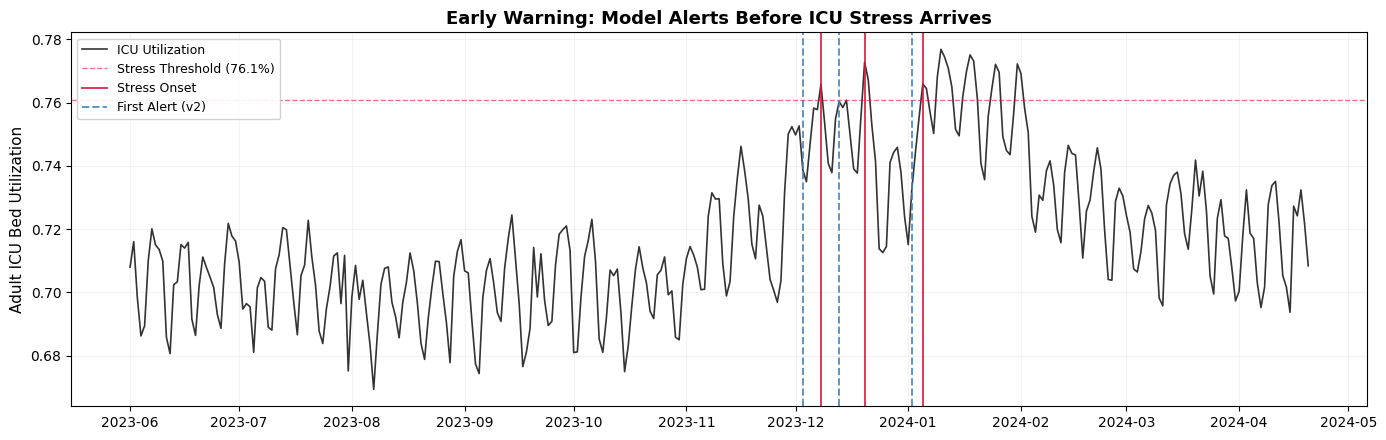

Saved to reports/early_warning_plot.png


In [32]:
# ── Clean summary plot: ICU utilization + v2 alert timing ──
fig, ax = plt.subplots(figsize=(14, 4.5))

# ICU utilization line
ax.plot(test_df.index, test_df[icu_col], color="#333333", linewidth=1.2, label="ICU Utilization")

# Stress threshold
ax.axhline(STRESS_THRESHOLD, color="crimson", linestyle="--", linewidth=1, alpha=0.6,
           label=f"Stress Threshold ({STRESS_THRESHOLD*100:.1f}%)")

# Mark each episode: crossing (red) and first v2 alert (blue dashed)
for i, crossing_date in enumerate(episode_first_crossings):
    kw_c = {"color": "crimson", "linewidth": 1.4, "alpha": 0.85}
    kw_a = {"color": "steelblue", "linewidth": 1.4, "linestyle": "--", "alpha": 0.85}
    if i == 0:
        kw_c["label"] = "Stress Onset"
        kw_a["label"] = "First Alert (v2)"
    ax.axvline(crossing_date, **kw_c)
    if episode_first_alerts_v2[i] is not None:
        ax.axvline(episode_first_alerts_v2[i], **kw_a)

ax.set_ylabel("Adult ICU Bed Utilization", fontsize=11)
ax.set_xlabel("")
ax.set_title("Early Warning: Model Alerts Before ICU Stress Arrives", fontsize=13, fontweight="bold")
ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.savefig("../reports/early_warning_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to reports/early_warning_plot.png")

## 10. Conclusion

A minimal logistic model using ICU utilization level and trend (v1) materially improves early stress detection over the heuristic baseline. Adding respiratory demand signals (v2) provides incremental value. All evaluation safeguards applied: locked threshold, strict chronological split, no temporal leakage, lead-time lookback matching the forecast horizon. Results are indicative rather than definitive due to the limited number of stress episodes.